In [1]:
import nibabel as nb 
import nilearn
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import datalad.api as dl
import os
import pandas as pd
os.environ["PATH"] = "/global/homes/m/mphagen/miniconda3/envs/fc_w_datalad/bin:" + os.environ["PATH"]
import pandas as pd

In [2]:
test_subs = np.loadtxt('../../../data/test_subjects.txt',dtype=str) 

In [3]:
from nilearn.plotting import plot_epi, plot_roi, show
import nilearn.image

In [4]:
bids_dir = '/pscratch/sd/m/mphagen/hcp-functional-connectivity'

In [5]:
tsnr_npys = glob('tsnr_resuts_old/*') 

In [6]:
finished = [] 
_ = [finished.append(ii.split('/')[-1].split('_')[0]) for ii in tsnr_npys]

In [7]:
# array_list = []
# result_array = np.zeros((91,109,91))
# for sub in test_subs: 
#     if sub not in finished: 
#         sub_dir = op.join(bids_dir, f'{sub}', 'MNINonLinear/Results/rfMRI_REST*/*.nii.gz')
#         sub_niftis = [] 
#         [sub_niftis.append(ii) for ii in glob(sub_dir) if '7T' not  in ii]     
#         for nifti_file in sub_niftis: 
#             dl.get(nifti_file, dataset=bids_dir)
#             nifti = nb.load(nifti_file)
#             nifti_data = nifti.get_fdata()
            
#             tsnr_array = np.mean(nifti_data,axis=3) / np.std(nifti_data,axis=3) 
#             tsnr_array[np.isnan(tsnr_array)] = 0 
#             np.save(f'tsnr_results/{sub}_{op.basename(nifti_file).replace('.nii.gz', '.npy')}', tsnr_array)
#             dl.drop(nifti_file, dataset=bids_dir)

In [8]:
#get a nifti to use for plotting
sub_dir = op.join(bids_dir, f'100206', 'MNINonLinear/Results/rfMRI_REST*/*.nii.gz')
sub_files = glob(sub_dir)
dl.get(sub_files[0], dataset=bids_dir)
nifti = nb.load(glob(sub_dir)[0])



In [9]:
tsnr_list = []
for ii in tsnr_npys: 
    tmp_array = np.load(ii) 
    tsnr_list.append(tmp_array) 
tsnr_avg = np.mean(tsnr_list, axis = 0) 

In [10]:
niimg = nb.Nifti1Image(tsnr_avg, nifti.affine)

In [11]:
# nilearn.plotting.plot_stat_map(niimg, display_mode='mosaic', vmin=0, title='Voxel-wise temporal signal-to-noise average from 364 scans')
# plt.savefig('tnsr_avg.png') 

In [12]:
schaefer = nilearn.datasets.fetch_atlas_schaefer_2018(n_rois=100) 

[fetch_atlas_schaefer_2018] Dataset found in /global/homes/m/mphagen/nilearn_data/schaefer_2018


In [13]:
from nilearn.maskers import NiftiLabelsMasker
masker = NiftiLabelsMasker(labels_img=schaefer.maps)

In [14]:
parc_nifti =  masker.fit_transform(niimg) 

In [15]:
results_path = '/global/homes/m/mphagen/functional-connectivity/connectome-comparison/results'

In [16]:
xcpd_lasso_df = pd.read_csv(op.join(results_path, 
                                    '2025-12-10_r2_lasso_xcpd.csv'))
#get average of problematic nodes across folds and subjects 
xcpd_lasso_nodes = xcpd_lasso_df.groupby('node').mean(numeric_only =True).mean(axis=1).sort_values() 

xcpd_lasso_nodes = xcpd_lasso_df.groupby('node').mean(numeric_only =True).mean(axis=1)
xcpd_lasso_nodes.index = [int(ii.replace('node_', '')) for ii in xcpd_lasso_nodes.index]
np.corrcoef(xcpd_lasso_nodes.sort_index() , parc_nifti)

array([[1.        , 0.72727843],
       [0.72727843, 1.        ]])

In [17]:
# b, a = np.polyfit(xcpd_lasso_nodes.sort_index(), parc_nifti, deg=1)

# # Create sequence of 100 numbers from 0 to 100
# xseq = np.linspace(-.4, 1, num=100)

# plt.scatter(xcpd_lasso_nodes.sort_index(), parc_nifti) 
# plt.plot(xseq, a + b * xseq, color="k", lw=2.5)
# plt.title('Temporal Signal to Noise vs R2 Averaged Across Participants') 
# plt.ylabel('Regional tSNR Across Participants')
# plt.xlabel('Average R2')
# plt.savefig('tsnr_vs_r2.png') 
# plt.show() 

In [18]:
xcpd_uoi_df = pd.read_csv(op.join(results_path, 
                                    '2025-12-10_r2_uoi_xcpd.csv'))
#get average of problematic nodes across folds and subjects 
xcpd_uoi_nodes = xcpd_uoi_df.groupby('node').mean(numeric_only =True).mean(axis=1).sort_values() 

xcpd_uoi_nodes = xcpd_uoi_df.groupby('node').mean(numeric_only =True).mean(axis=1)
xcpd_uoi_nodes.index = [int(ii.replace('node_', '')) for ii in xcpd_uoi_nodes.index]
np.corrcoef(xcpd_uoi_nodes.sort_index() , parc_nifti)

array([[1.        , 0.72842835],
       [0.72842835, 1.        ]])

In [19]:
msmall_uoi_df = pd.read_csv(op.join(results_path, 
                                    '2025-12-10_r2_uoi_msmall.csv'))
#get average of problematic nodes across folds and subjects 
msmall_uoi_nodes = msmall_uoi_df.groupby('node').mean(numeric_only =True).mean(axis=1).sort_values() 

msmall_uoi_nodes = msmall_uoi_df.groupby('node').mean(numeric_only =True).mean(axis=1)
msmall_uoi_nodes.index = [int(ii.replace('node_', '')) for ii in msmall_uoi_nodes.index]
np.corrcoef(msmall_uoi_nodes.sort_index() , parc_nifti)

array([[1.      , 0.793206],
       [0.793206, 1.      ]])

In [20]:
msmall_lasso_df = pd.read_csv(op.join(results_path, 
                                    '2025-12-10_r2_lasso_msmall.csv'))
#get average of problematic nodes across folds and subjects 
msmall_lasso_nodes = msmall_lasso_df.groupby('node').mean(numeric_only =True).mean(axis=1).sort_values() 

msmall_lasso_nodes = msmall_lasso_df.groupby('node').mean(numeric_only =True).mean(axis=1)
msmall_lasso_nodes.index = [int(ii.replace('node_', '')) for ii in msmall_lasso_nodes.index]
np.corrcoef(msmall_lasso_nodes.sort_index() , parc_nifti)

array([[1.        , 0.79518708],
       [0.79518708, 1.        ]])

In [21]:
import seaborn as sns

In [22]:
color_dict = sns.color_palette()

In [23]:
sns.color_palette()


[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [24]:
plt.rcParams["font.size"] = 10

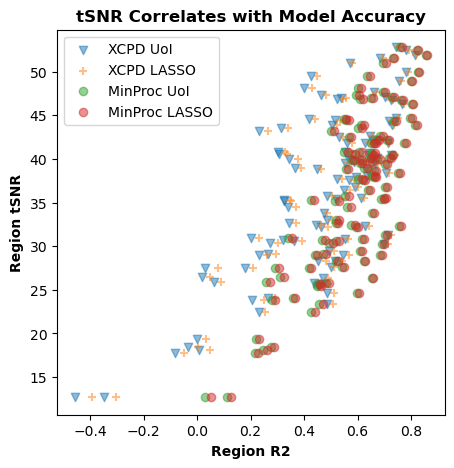

In [26]:
b, a = np.polyfit(xcpd_uoi_nodes.sort_index(), parc_nifti, deg=1)

# Create sequence of 100 numbers from 0 to 100
xseq = np.linspace(-.4, 1, num=100)
plt.figure(figsize=(5,5))
plt.scatter(xcpd_uoi_nodes.sort_index(), parc_nifti, 
            label='XCPD UoI', alpha=.5, marker= 'v',
            
           ) 
plt.scatter(xcpd_lasso_nodes.sort_index(), parc_nifti, 
            label='XCPD LASSO', alpha=.5, marker = '+') 
plt.scatter(msmall_uoi_nodes.sort_index(), parc_nifti,
            label='MinProc UoI', alpha=.5) 
plt.scatter(msmall_lasso_nodes.sort_index(), parc_nifti,
            label='MinProc LASSO', alpha=.5) 
plt.legend()
# plt.plot(xseq, a + b * xseq, color="k", lw=2.5)
plt.title('tSNR Correlates with Model Accuracy', 
         weight='bold') 
plt.ylabel('Region tSNR', weight='semibold')
plt.xlabel('Region R2', weight='semibold')
plt.savefig('../02-Analysis/plots/2025-12-12_tsnr_vs_r2.png',
             bbox_inches='tight', 
            transparent=True)
plt.show() 